## Classify cells into pyramidal or interneurons

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ignore datajoint+jupyter async warnings
import warnings
warnings.simplefilter('ignore', category=DeprecationWarning)
warnings.simplefilter('ignore', category=ResourceWarning)

from spyglass.common import (Session, IntervalList,LabMember, LabTeam, Raw, Session, Nwbfile,
                            Electrode,LFPBand,interval_list_intersect)
from spyglass.common import TaskEpoch
import spyglass.spikesorting.v0 as ss

from spyglass.spikesorting.v0 import (SortGroup, 
                                    SortInterval,
                                    SpikeSortingPreprocessingParameters,
                                    SpikeSortingRecording, 
                                    SpikeSorterParameters,
                                    SpikeSortingRecordingSelection,
                                    ArtifactDetectionParameters, ArtifactDetectionSelection,
                                    ArtifactRemovedIntervalList, ArtifactDetection,
                                      SpikeSortingSelection, SpikeSorting,
                                   CuratedSpikeSortingSelection,CuratedSpikeSorting,Curation)
from spyglass.spikesorting.v0.curation_figurl import CurationFigurl,CurationFigurlSelection
from spyglass.spikesorting.v0.spikesorting_curation import MetricParameters,MetricSelection,QualityMetrics
from spyglass.spikesorting.v0.spikesorting_curation import WaveformParameters,WaveformSelection,Waveforms
from spyglass.common.common_position import IntervalPositionInfo, IntervalPositionInfoSelection,IntervalLinearizedPosition

from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from pprint import pprint
from spyglass.shijiegu.ripple_detection import removeDataBeforeTrial1
from spyglass.shijiegu.helpers import interpolate_to_new_time
from spyglass.shijiegu.placefield import place_field,placefield_to_peak1dloc
from spyglass.shijiegu.Analysis_SGU import DecodeResultsLinear#, SingleUnit
warnings.simplefilter("ignore", category=DeprecationWarning)
warnings.simplefilter("ignore", category=ResourceWarning)
warnings.filterwarnings('ignore')

[2025-12-01 11:28:43,316][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [4]:
import matplotlib
from spyglass.shijiegu.helpers import interval_union
from spyglass.shijiegu.Analysis_SGU import SingleUnit, TrialChoice,RippleTimes,TetrodeNumber,EpochPos,ExtendedRippleTimes,RippleTimesWithDecode
from spyglass.shijiegu.load import load_run_sessions
from spyglass.shijiegu.singleUnit import (do_mountainSort,electrode_unit,RippleTime2FiringRate,findWaveForms,RippleTime2Index,find_spikes
                            )
from spyglass.shijiegu.singleUnit_classification import (fill_single_unit_classification, get_spike_info,return_AC_mean,return_spike_width, classify, result_to_dict, result_to_dataframe)

from spyglass.shijiegu.fragmented import permute_frag_cont,find_spike_count_ratio,get_nwb_units,classify_cells,find_firing_cross_correlation
from spyglass.shijiegu.placefield import cell_by_arm


### list of files

In [5]:
dates_to_plot_animals = {}
dates_to_plot_checked_animals = {}
success_animals = {}

animal = 'eliot'
dates_to_plot_animals[animal] = ['20221018','20221019','20221021','20221022','20221023','20221024']

animal = 'molly'
dates_to_plot_animals[animal] = ['20220418']

animal = "lewis"
dates_to_plot_animals[animal] = ["20240107", "20240108","20240109",	"20240110","20240113"]

animal = "julio"
dates_to_plot_animals[animal] = ["20230801", "20230802","20230805","20230806"]

animal = "klein"
dates_to_plot_animals[animal] = ["20231101", "20231102", "20231105", "20231106", "20231107", "20231108", "20231109"]

In [6]:
bad_sessions = [('eliot', '20221019', '10_Seq2Session5'),
               ('molly', '20220418', '06_Seq2Session3'),
               ('molly', '20220418', '08_Seq2Session4'),
               ('molly', '20220418', '10_Seq2Session5'),
               ('julio', '20230802', '02_Seq2Session1'),
               ('julio', '20230802', '04_Seq2Session2'),
               ('julio', '20230802', '06_Seq2Session3'),
               ('julio', '20230802', '08_Seq2Session4'),
               ('lewis', '20240108', '06_Rev2Session3'), # whole session missing
               ('lewis', '20240108', '08_Rev2Session4'), # whole session missing
               ('lewis', '20240113', '02_Rev2Session1'), # miss sort group 0
               ('klein', '20231101', '12_Rev2Session6')] # these sessions have incomplete number of sorted tetrodes

### check if there are sorted data for each file

In [108]:
for animal in dates_to_plot_animals.keys():
    dates_to_plot_checked_animals[animal] = []
    
    for d in dates_to_plot_animals[animal]:
        nwb_copy_file_name = f"{animal}{d}_.nwb"
        run_session_ids, run_session_names, pos_session_names = load_run_sessions(nwb_copy_file_name)
        for session_name in run_session_names:
            key = {"nwb_file_name": nwb_copy_file_name,
                   "sorter":"mountainsort4",
                   "sort_interval_name":session_name,
                   "curation_id":1}
            if (animal, d, session_name) in bad_sessions:
                continue

            if len(CuratedSpikeSorting() & key) > 0:
                print((animal, d, session_name))
                print("Sort group number:", len(CuratedSpikeSorting() & key))
                dates_to_plot_checked_animals[animal].append((d,session_name))

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
eliot20221018_ 1         01_Seq2Sleep1  pos 0 valid ti
eliot20221018_ 2         02_Seq2Session pos 1 valid ti
eliot20221018_ 3         03_Seq2Sleep2  pos 2 valid ti
eliot20221018_ 4         04_Seq2Session pos 3 valid ti
eliot20221018_ 5         05_Seq2Session pos 4 valid ti
eliot20221018_ 6         06_Seq2Sleep3  pos 5 valid ti
eliot20221018_ 7         07_Seq2Session pos 6 valid ti
eliot20221018_ 8         08_Seq2Sleep4  pos 7 valid ti
eliot20221018_ 9         09_Seq2Session pos 8 valid ti
eliot20221018_ 10        10_Seq2Sleep5  pos 9 valid ti
eliot20221018_ 11        11_Seq2Session pos 10 valid t
eliot20221018_ 12        12_Seq2Sleep6  pos 11 valid t
 (Total: 12)

('eliot', '20221018', '02_Seq2Session1')
Sort group number: 16
('eliot', '20221018', '04_Seq2Session2')
Sort group number: 16
('eliot', '20221018', '05_Seq2Session3')
Sort group number: 16
('eliot', '20221018', '07_S

### classify and insert into database

In [109]:
dates_to_plot_checked_animals

{'eliot': [('20221018', '02_Seq2Session1'),
  ('20221018', '04_Seq2Session2'),
  ('20221018', '05_Seq2Session3'),
  ('20221018', '07_Seq2Session4'),
  ('20221018', '09_Seq2Session5'),
  ('20221018', '11_Seq2Session6'),
  ('20221019', '02_Seq2Session1'),
  ('20221019', '04_Seq2Session2'),
  ('20221019', '06_Seq2Session3'),
  ('20221019', '08_Seq2Session4'),
  ('20221021', '02_Seq2Session1'),
  ('20221021', '04_Seq2Session2'),
  ('20221021', '06_Seq2Session3'),
  ('20221021', '08_Seq2Session4'),
  ('20221022', '02_Seq2Session1'),
  ('20221022', '04_Seq2Session2'),
  ('20221022', '06_Seq2Session3'),
  ('20221022', '08_Seq2Session4'),
  ('20221022', '10_Seq2Session5'),
  ('20221023', '02_Seq2Session1'),
  ('20221023', '04_Seq2Session2'),
  ('20221023', '06_Seq2Session3'),
  ('20221023', '08_Seq2Session4'),
  ('20221024', '02_Seq2Session2'),
  ('20221024', '04_Seq2Session3'),
  ('20221024', '06_Seq2Session4'),
  ('20221024', '08_Seq2Session5'),
  ('20221024', '10_Seq2Session6')],
 'molly': 

In [ ]:
for animal in dates_to_plot_animals.keys():
    for d_session in dates_to_plot_checked_animals[animal]:
        d, session_name = d_session
        nwb_copy_file_name = f"{animal}{d}_.nwb"
        print(f"Processing file {nwb_copy_file_name} session {session_name}...")
        try:
            success_animals[(animal, d, session_name)] = fill_single_unit_classification(nwb_copy_file_name, session_name, insert = True)
        except:
            success_animals[(animal, d, session_name)] = False

[2025-11-26 16:03:17,584][WARNING]: Skipped checksum for file with hash: 02c1904a-fda7-83cb-f181-39905a7772be, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_ORXBMEA1FO.nwb
[2025-11-26 16:03:17,590][WARNING]: Skipped checksum for file with hash: 02c1904a-fda7-83cb-f181-39905a7772be, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_ORXBMEA1FO.nwb
[2025-11-26 16:03:17,597][WARNING]: Skipped checksum for file with hash: 02c1904a-fda7-83cb-f181-39905a7772be, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_ORXBMEA1FO.nwb
[2025-11-26 16:03:17,603][WARNING]: Skipped checksum for file with hash: 02c1904a-fda7-83cb-f181-39905a7772be, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_ORXBMEA1FO.nwb
[2025-11-26 16:03:17,620][WARNING]: Skipped checksum for file with hash: b6a9af23-7821-6baf-3ffb-eab6a2d67dbd, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_99VZD04ISZ.nwb
[2025-11-26 16:03:17,628][WARNING]: Skipped checksum for file with hash: b6

Processing file eliot20221018_.nwb session 02_Seq2Session1...


[2025-11-26 16:03:17,767][WARNING]: Skipped checksum for file with hash: dc0317f4-66bd-0876-9e3f-a02bd135eee3, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_0JWXRF9QUB.nwb
[2025-11-26 16:03:17,774][WARNING]: Skipped checksum for file with hash: dc0317f4-66bd-0876-9e3f-a02bd135eee3, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_0JWXRF9QUB.nwb
[2025-11-26 16:03:17,785][WARNING]: Skipped checksum for file with hash: dc0317f4-66bd-0876-9e3f-a02bd135eee3, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_0JWXRF9QUB.nwb
[2025-11-26 16:03:17,803][WARNING]: Skipped checksum for file with hash: 082f33a5-b7e3-4666-a0be-305f67c919f8, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_U56QDILNO9.nwb
[2025-11-26 16:03:17,810][WARNING]: Skipped checksum for file with hash: 082f33a5-b7e3-4666-a0be-305f67c919f8, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_U56QDILNO9.nwb
[2025-11-26 16:03:17,817][WARNING]: Skipped checksum for file with hash: 08

sort groups are:  [0, 2, 13, 14, 16, 17, 20, 23, 26, 28, 29, 30, 31]
working on electrode 0
working on electrode 0 unit 3
working on electrode 2
working on electrode 2 unit 2


/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/spikeinterface/core/base.py:1038: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.98.2 is recommended
  warnings.warn(


...

sort groups are:  [2, 3, 6, 7, 12, 15, 20, 22, 26, 27, 28, 29, 30, 31, 36, 43, 45, 49, 51, 55, 56, 61]
working on electrode 2
working on electrode 2 unit 2
working on electrode 2 unit 4
working on electrode 2 unit 5
working on electrode 2 unit 6
working on electrode 2 unit 9
working on electrode 3
working on electrode 3 unit 2
working on electrode 3 unit 3
working on electrode 3 unit 4
working on electrode 3 unit 6
working on electrode 3 unit 7
working on electrode 3 unit 8
working on electrode 3 unit 9
working on electrode 3 unit 11
working on electrode 3 unit 13
working on electrode 3 unit 14
working on electrode 3 unit 15
working on electrode 3 unit 16
working on electrode 3 unit 18
working on electrode 6
working on electrode 6 unit 2
working on electrode 6 unit 3
working on electrode 6 unit 4
working on electrode 6 unit 5
working on electrode 6 unit 6
working on electrode 6 unit 10
working on electrode 6 unit 11
working on electrode 6 unit 12
working on electrode 6 unit 13
working 

[2025-11-26 20:32:57,549][WARNING]: Skipped checksum for file with hash: 1ed18498-5cb3-b704-b889-1c3fedae1d45, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_JLPC639YW2.nwb
[2025-11-26 20:32:57,557][WARNING]: Skipped checksum for file with hash: 1ed18498-5cb3-b704-b889-1c3fedae1d45, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_JLPC639YW2.nwb
[2025-11-26 20:32:57,567][WARNING]: Skipped checksum for file with hash: 1ed18498-5cb3-b704-b889-1c3fedae1d45, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_JLPC639YW2.nwb
[2025-11-26 20:32:57,572][WARNING]: Skipped checksum for file with hash: 1ed18498-5cb3-b704-b889-1c3fedae1d45, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_JLPC639YW2.nwb


Processing file julio20230805_.nwb session 04_Seq2Session2...


/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'ndx-franklab-novela' version 0.1.0 because version 0.2.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
[2025-11-26 20:33:07,740][WARNING]: Skipped checksum for file with hash: f77885a2-c7a9-e98a-0440-7abc90b3995c, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_OXNOYV4UK1.nwb
[2025-11-26 20:33:07,748][WARNING]: Skipped checksum for file with hash: f77885a2-c7a9-e98a-0440-7abc90b3995c, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_OXNOYV4UK1.nwb
[2025-11-26 20:33:07,757][WARNING]: Skipped checksum for file with hash: f77885a2-c7a9-e98a-0440-7abc90b3995c, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_OXNOYV4UK1.nwb
[2025-11-26 20:33:07,761][WARNING]: Skipped checksum for file with hash: f77885a2-c7a9-e98a-0440-7abc90b3995c, and path: /stelmo/nwb/analysis/Ju

sort groups are:  [2, 3, 6, 7, 8, 12, 15, 20, 22, 26, 27, 28, 30, 31, 36, 43, 45, 49, 51, 55, 56, 61]
working on electrode 2
working on electrode 2 unit 1
working on electrode 2 unit 4
working on electrode 2 unit 5
working on electrode 2 unit 7
working on electrode 2 unit 8
working on electrode 2 unit 9
working on electrode 2 unit 10
working on electrode 2 unit 16
working on electrode 3
working on electrode 3 unit 3
working on electrode 3 unit 4
working on electrode 3 unit 5
working on electrode 3 unit 7
working on electrode 3 unit 8
working on electrode 3 unit 10
working on electrode 3 unit 11
working on electrode 3 unit 12
working on electrode 3 unit 13
working on electrode 3 unit 14
working on electrode 3 unit 16
working on electrode 3 unit 17
working on electrode 6
working on electrode 6 unit 2
working on electrode 6 unit 3
working on electrode 6 unit 4
working on electrode 6 unit 5
working on electrode 6 unit 6
working on electrode 6 unit 8
working on electrode 6 unit 9
working on

In [120]:
success_animals

{('eliot', '20221018', '02_Seq2Session1'): False,
 ('eliot', '20221018', '04_Seq2Session2'): False,
 ('eliot', '20221018', '05_Seq2Session3'): False,
 ('eliot', '20221018', '07_Seq2Session4'): False,
 ('eliot', '20221018', '09_Seq2Session5'): False,
 ('eliot', '20221018', '11_Seq2Session6'): False,
 ('eliot', '20221019', '02_Seq2Session1'): False,
 ('eliot', '20221019', '04_Seq2Session2'): False,
 ('eliot', '20221019', '06_Seq2Session3'): False,
 ('eliot', '20221019', '08_Seq2Session4'): False,
 ('eliot', '20221021', '02_Seq2Session1'): True,
 ('eliot', '20221021', '04_Seq2Session2'): True,
 ('eliot', '20221021', '06_Seq2Session3'): True,
 ('eliot', '20221021', '08_Seq2Session4'): True,
 ('eliot', '20221022', '02_Seq2Session1'): True,
 ('eliot', '20221022', '04_Seq2Session2'): True,
 ('eliot', '20221022', '06_Seq2Session3'): True,
 ('eliot', '20221022', '08_Seq2Session4'): True,
 ('eliot', '20221022', '10_Seq2Session5'): True,
 ('eliot', '20221023', '02_Seq2Session1'): True,
 ('eliot',

### debug

In [115]:
key = {"nwb_file_name": "lewis20240113_.nwb",
       "sorter":"mountainsort4",
       "sort_interval_name":'02_Rev2Session1',
       "curation_id":1}
CuratedSpikeSorting() & key


curation_id a number correponding to the index of this curation,nwb_file_name name of the NWB file,sort_group_id identifier for a group of electrodes,sort_interval_name name for this interval,preproc_params_name,team_name,sorter,sorter_params_name,artifact_removed_interval_list_name,analysis_file_name name of the file,units_object_id
1,lewis20240113_.nwb,1,02_Rev2Session1,franklab_tetrode_hippocampus,SequenceTask,mountainsort4,CA1_tet_Shijie_whiten,lewis20240113_.nwb_02_Rev2Session1_1_franklab_tetrode_hippocampus_ampl_1500_prop_075_1ms_artifact_removed_valid_times_track_time_only,lewis20240113_74YNSCA9FJ.nwb,a0f09a6d-c7b8-48ad-b186-6bdea78b895b
1,lewis20240113_.nwb,7,02_Rev2Session1,franklab_tetrode_hippocampus,SequenceTask,mountainsort4,CA1_tet_Shijie_whiten,lewis20240113_.nwb_02_Rev2Session1_7_franklab_tetrode_hippocampus_ampl_1500_prop_075_1ms_artifact_removed_valid_times_track_time_only,lewis20240113_7WU475EVQ0.nwb,1025fd1d-d8ac-4ec5-924c-3d890056161a
1,lewis20240113_.nwb,8,02_Rev2Session1,franklab_tetrode_hippocampus,SequenceTask,mountainsort4,CA1_tet_Shijie_whiten,lewis20240113_.nwb_02_Rev2Session1_8_franklab_tetrode_hippocampus_ampl_1500_prop_075_1ms_artifact_removed_valid_times_track_time_only,lewis20240113_ROFXHWEUHB.nwb,fb7816f4-f8bb-42b5-aa91-cb0f7a4c45a0
1,lewis20240113_.nwb,9,02_Rev2Session1,franklab_tetrode_hippocampus,SequenceTask,mountainsort4,CA1_tet_Shijie_whiten,lewis20240113_.nwb_02_Rev2Session1_9_franklab_tetrode_hippocampus_ampl_1500_prop_075_1ms_artifact_removed_valid_times_track_time_only,lewis20240113_TRYG0XBL4D.nwb,f48e1f41-55c4-4377-ac57-d59b308c9e14
1,lewis20240113_.nwb,12,02_Rev2Session1,franklab_tetrode_hippocampus,SequenceTask,mountainsort4,CA1_tet_Shijie_whiten,lewis20240113_.nwb_02_Rev2Session1_12_franklab_tetrode_hippocampus_ampl_1500_prop_075_1ms_artifact_removed_valid_times_track_time_only,lewis20240113_928CK9468U.nwb,467a18b2-4e0e-4696-95dc-685caf423d64
1,lewis20240113_.nwb,13,02_Rev2Session1,franklab_tetrode_hippocampus,SequenceTask,mountainsort4,CA1_tet_Shijie_whiten,lewis20240113_.nwb_02_Rev2Session1_13_franklab_tetrode_hippocampus_ampl_1500_prop_075_1ms_artifact_removed_valid_times_track_time_only,lewis20240113_T6UFA6HMAT.nwb,db51d6b7-6df7-4cda-bae3-230e5ce17bed
1,lewis20240113_.nwb,15,02_Rev2Session1,franklab_tetrode_hippocampus,SequenceTask,mountainsort4,CA1_tet_Shijie_whiten,lewis20240113_.nwb_02_Rev2Session1_15_franklab_tetrode_hippocampus_ampl_1500_prop_075_1ms_artifact_removed_valid_times_track_time_only,lewis20240113_GUOXLWRPGK.nwb,c0821c31-9a9e-4716-96f8-df80961ecbd1
1,lewis20240113_.nwb,17,02_Rev2Session1,franklab_tetrode_hippocampus,SequenceTask,mountainsort4,CA1_tet_Shijie_whiten,lewis20240113_.nwb_02_Rev2Session1_17_franklab_tetrode_hippocampus_ampl_1500_prop_075_1ms_artifact_removed_valid_times_track_time_only,lewis20240113_FHY20Y5ER6.nwb,3809ef91-7ac6-4542-84a4-a09490b0a443
1,lewis20240113_.nwb,18,02_Rev2Session1,franklab_tetrode_hippocampus,SequenceTask,mountainsort4,CA1_tet_Shijie_whiten,lewis20240113_.nwb_02_Rev2Session1_18_franklab_tetrode_hippocampus_ampl_1500_prop_075_1ms_artifact_removed_valid_times_track_time_only,lewis20240113_L7U5DZ9K3N.nwb,29e23bfd-c2f0-4775-b7e3-02a06e2ce9ff
1,lewis20240113_.nwb,19,02_Rev2Session1,franklab_tetrode_hippocampus,SequenceTask,mountainsort4,CA1_tet_Shijie_whiten,lewis20240113_.nwb_02_Rev2Session1_19_franklab_tetrode_hippocampus_ampl_1500_prop_075_1ms_artifact_removed_valid_times_track_time_only,lewis20240113_B6VMH1J2WR.nwb,e48cfa1e-4960-42c9-9bca-fbef6fbbc142


In [97]:
%debug

> /home/shijiegu/Documents/spyglass/src/spyglass/shijiegu/singleUnit.py(187)electrode_unit()
    185     key["sort_group_id"] = sort_group_id
    186 
--> 187     nwb_units_query = (CuratedSpikeSorting() & key).fetch_nwb()[0]
    188 
    189     if len(nwb_units_query['units_object_id']) == 0:



ipdb>  key


{'nwb_file_name': 'eliot20221019_.nwb', 'sorter': 'mountainsort4', 'sort_interval_name': '10_Seq2Session5', 'curation_id': 1, 'sort_group_id': 20}


ipdb>  key = {'nwb_file_name': 'eliot20221019_.nwb', 'sorter': 'mountainsort4', 'sort_interval_name': '10_Seq2Session5', 'curation_id': 1}
ipdb>  (CuratedSpikeSorting() & key)


*curation_id   *nwb_file_name *sort_group_id *sort_interval *preproc_param *team_name    *sorter        *sorter_params *artifact_remo analysis_file_ units_object_i
+------------+ +------------+ +------------+ +------------+ +------------+ +-----------+ +------------+ +------------+ +------------+ +------------+ +------------+
1              eliot20221019_ 0              10_Seq2Session franklab_tetro Shijie Gu     mountainsort4  CA1_tet_Shijie eliot20221019_ eliot20221019_ fbb47bfa-1267-
1              eliot20221019_ 2              10_Seq2Session franklab_tetro Shijie Gu     mountainsort4  CA1_tet_Shijie eliot20221019_ eliot20221019_ dea5b10f-520a-
1              eliot20221019_ 4              10_Seq2Session franklab_tetro Shijie Gu     mountainsort4  CA1_tet_Shijie eliot20221019_ eliot20221019_               
1              eliot20221019_ 5              10_Seq2Session franklab_tetro Shijie Gu     mountainsort4  CA1_tet_Shijie eliot20221019_ eliot20221019_ 7f18e86b-b8c3-
1              e

ipdb>  exit


In [91]:
Waveforms & {'nwb_file_name':nwb_copy_file_name, 'sort_interval_name':session_name}

curation_id a number correponding to the index of this curation,nwb_file_name name of the NWB file,sort_group_id identifier for a group of electrodes,sort_interval_name name for this interval,preproc_params_name,team_name,sorter,sorter_params_name,artifact_removed_interval_list_name,waveform_params_name name of waveform extraction parameters,waveform_extractor_path,analysis_file_name name of the file,waveforms_object_id Object ID for the waveforms in NWB file
0,eliot20221018_.nwb,0,02_Seq2Session1,franklab_tetrode_hippocampus,Shijie Gu,mountainsort4,CA1_tet_Shijie_whiten,eliot20221018_.nwb_02_Seq2Session1_0_franklab_tetrode_hippocampus_ampl_1500_prop_075_1ms_artifact_removed_valid_times_track_time_only,default_clusterless,/stelmo/nwb/waveforms/eliot20221018_.nwb_772c0675_0_default_clusterless_waveforms,eliot20221018_Z3LWL88EG2.nwb,c7cc6880-0d2e-43c6-b417-a1e8c29eff54
0,eliot20221018_.nwb,2,02_Seq2Session1,franklab_tetrode_hippocampus,Shijie Gu,mountainsort4,CA1_tet_Shijie_whiten,eliot20221018_.nwb_02_Seq2Session1_2_franklab_tetrode_hippocampus_ampl_1500_prop_075_1ms_artifact_removed_valid_times_track_time_only,default_clusterless,/stelmo/nwb/waveforms/eliot20221018_.nwb_173450bf_0_default_clusterless_waveforms,eliot20221018_1WQP82XZCE.nwb,21f2c02e-99c9-4bfa-b3b1-d8f702fb8d4e
0,eliot20221018_.nwb,4,02_Seq2Session1,franklab_tetrode_hippocampus,Shijie Gu,mountainsort4,CA1_tet_Shijie_whiten,eliot20221018_.nwb_02_Seq2Session1_4_franklab_tetrode_hippocampus_ampl_1500_prop_075_1ms_artifact_removed_valid_times_track_time_only,default_clusterless,/stelmo/nwb/waveforms/eliot20221018_.nwb_6c6ad42a_0_default_clusterless_waveforms,eliot20221018_YVQRFPCCRJ.nwb,f6ceeadd-2464-4975-8447-fe394487ade3
0,eliot20221018_.nwb,5,02_Seq2Session1,franklab_tetrode_hippocampus,Shijie Gu,mountainsort4,CA1_tet_Shijie_whiten,eliot20221018_.nwb_02_Seq2Session1_5_franklab_tetrode_hippocampus_ampl_1500_prop_075_1ms_artifact_removed_valid_times_track_time_only,default_clusterless,/stelmo/nwb/waveforms/eliot20221018_.nwb_76e289ed_0_default_clusterless_waveforms,eliot20221018_VMR5PRRUZI.nwb,02a91ecd-2ec1-47ab-b7ae-9a9deb305772
0,eliot20221018_.nwb,13,02_Seq2Session1,franklab_tetrode_hippocampus,Shijie Gu,mountainsort4,CA1_tet_Shijie_whiten,eliot20221018_.nwb_02_Seq2Session1_13_franklab_tetrode_hippocampus_ampl_1500_prop_075_1ms_artifact_removed_valid_times_track_time_only,default_clusterless,/stelmo/nwb/waveforms/eliot20221018_.nwb_a79fcfd5_0_default_clusterless_waveforms,eliot20221018_2GN808CO63.nwb,6c38072e-743e-47fa-9bc1-c8e6c429bbc5
0,eliot20221018_.nwb,14,02_Seq2Session1,franklab_tetrode_hippocampus,Shijie Gu,mountainsort4,CA1_tet_Shijie_whiten,eliot20221018_.nwb_02_Seq2Session1_14_franklab_tetrode_hippocampus_ampl_1500_prop_075_1ms_artifact_removed_valid_times_track_time_only,default_clusterless,/stelmo/nwb/waveforms/eliot20221018_.nwb_572fdd02_0_default_clusterless_waveforms,eliot20221018_8JM0Q4698D.nwb,f4384f20-9fa8-402d-bb2b-6cd596ada156
0,eliot20221018_.nwb,16,02_Seq2Session1,franklab_tetrode_hippocampus,Shijie Gu,mountainsort4,CA1_tet_Shijie_whiten,eliot20221018_.nwb_02_Seq2Session1_16_franklab_tetrode_hippocampus_ampl_1500_prop_075_1ms_artifact_removed_valid_times_track_time_only,default_clusterless,/stelmo/nwb/waveforms/eliot20221018_.nwb_5da16764_0_default_clusterless_waveforms,eliot20221018_K873P4XQQ0.nwb,1754b7b5-5af2-42d8-bd7d-1068960bc9fe
0,eliot20221018_.nwb,17,02_Seq2Session1,franklab_tetrode_hippocampus,Shijie Gu,mountainsort4,CA1_tet_Shijie_whiten,eliot20221018_.nwb_02_Seq2Session1_17_franklab_tetrode_hippocampus_ampl_1500_prop_075_1ms_artifact_removed_valid_times_track_time_only,default_clusterless,/stelmo/nwb/waveforms/eliot20221018_.nwb_fc3d7e7d_0_default_clusterless_waveforms,eliot20221018_UH4BZL3EOA.nwb,0e254a18-50cb-4ec1-bd8a-91a9a1c1dd53
0,eliot20221018_.nwb,20,02_Seq2Session1,franklab_tetrode_hippocampus,Shijie Gu,mountainsort4,CA1_tet_Shijie_whiten,eliot20221018_.nwb_02_Seq2Session1_20_franklab_tetrode_hippocampus_ampl_1500_prop_075

# Below are for debugging

### 1. Classify cells in this session

In [34]:
key = {"nwb_file_name": nwb_copy_file_name,
       "sorter":"mountainsort4",
       "sort_interval_name":session_name,
       "curation_id":1}

sort_group_ids = np.unique((QualityMetrics & key).fetch("sort_group_id"))
sort_group_ids_with_good_cell = []
nwb_units_all = {}
for sort_group_id in sort_group_ids:
    nwb_units = electrode_unit(nwb_copy_file_name,session_name,sort_group_id,curation_id = 1)
    if nwb_units is None or len(nwb_units)==0:
        continue
    sort_group_ids_with_good_cell.append(sort_group_id)
    nwb_units_all[sort_group_id] = nwb_units
print("sort groups are: ",sort_group_ids_with_good_cell)

[2025-11-25 12:19:10,811][WARNING]: Skipped checksum for file with hash: d1aee99e-e7ff-cdc7-2ea5-f40023b929d5, and path: /stelmo/nwb/analysis/Julio20230806/Julio20230806_A3HJC3N99P.nwb
[2025-11-25 12:19:10,820][WARNING]: Skipped checksum for file with hash: d1aee99e-e7ff-cdc7-2ea5-f40023b929d5, and path: /stelmo/nwb/analysis/Julio20230806/Julio20230806_A3HJC3N99P.nwb
[2025-11-25 12:19:10,829][WARNING]: Skipped checksum for file with hash: d1aee99e-e7ff-cdc7-2ea5-f40023b929d5, and path: /stelmo/nwb/analysis/Julio20230806/Julio20230806_A3HJC3N99P.nwb
[2025-11-25 12:19:10,834][WARNING]: Skipped checksum for file with hash: d1aee99e-e7ff-cdc7-2ea5-f40023b929d5, and path: /stelmo/nwb/analysis/Julio20230806/Julio20230806_A3HJC3N99P.nwb
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'ndx-franklab-novela' version 0.1.0 because version 0.2.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %

sort groups are:  [2, 3, 6, 7, 8, 12, 15, 20, 22, 26, 27, 28, 29, 30, 31, 36, 43, 45, 49, 51, 55, 56, 61]


In [35]:
firing_rate, ac_mean, width = get_spike_info(nwb_units_all, nwb_copy_file_name, session_name)

working on electrode 2
working on electrode 2 unit 2
working on electrode 2 unit 4
working on electrode 2 unit 5
working on electrode 2 unit 6
working on electrode 2 unit 7
working on electrode 2 unit 10
working on electrode 2 unit 12
working on electrode 3
working on electrode 3 unit 2
working on electrode 3 unit 3
working on electrode 3 unit 4
working on electrode 3 unit 5
working on electrode 3 unit 6
working on electrode 3 unit 8
working on electrode 3 unit 9
working on electrode 3 unit 10
working on electrode 3 unit 11
working on electrode 3 unit 13
working on electrode 3 unit 14
working on electrode 3 unit 15
working on electrode 3 unit 16
working on electrode 6
working on electrode 6 unit 2
working on electrode 6 unit 3
working on electrode 6 unit 4
working on electrode 6 unit 5
working on electrode 6 unit 6
working on electrode 6 unit 7
working on electrode 6 unit 11
working on electrode 6 unit 12
working on electrode 6 unit 13
working on electrode 6 unit 14
working on electrod

In [36]:
# Pyramidal cells
#  criterion from Skaggs 1996: 
#  1. have a spike width (peak to valley) of at least 300 us; and 4)
#  2. have an overall mean rate below 5 Hz during the recording session. 
#

# Interneuron a unit was required to
#  1. have a spike width less than 300 us;
#  2. fire with a mean rate above 5 Hz during the recording session.

classification = classify(firing_rate, ac_mean, width)

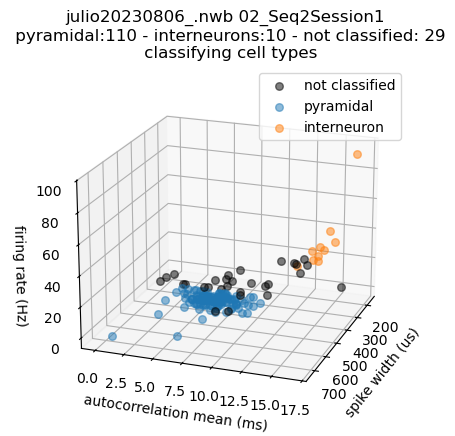

In [47]:
# Create a figure and a 3D axes
fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(projection='3d')

# Plot the 3D scatter points
type_p, type_i, type_k = 0, 0, 0
for (e,u) in firing_rate.keys():
    fr = firing_rate[(e,u)]
    ac = ac_mean[(e,u)]
    w = np.abs(width[(e,u)])
    c = classification[(e,u)]
    if c == "pyramidal":
        color = 'C0'
        if type_p == 0:
            label = "pyramidal"
        else:
            label = None
        type_p += 1
    elif c == "interneuron":
        color = 'C1'
        if type_i == 0:
            label = "interneuron"
        else:
            label = None
        type_i += 1
    else:
        color = 'k'
        if type_k == 0:
            label = "not classified"
        else:
            label = None
        type_k += 1
    ax.scatter(w * 1000, ac, fr, s=30, color = color, label = label, alpha = 0.5)

# Set labels
ax.set_zlabel("firing rate (Hz)")
ax.set_ylabel("autocorrelation mean (ms)")
ax.set_xlabel('spike width (us)')

# Display the plot
ax.view_init(elev=20, azim=20) 
plt.title(
    f'{nwb_copy_file_name} {session_name} \n pyramidal:{int(type_p)} - interneurons:{int(type_i)} - not classified: {int(type_k)}\n classifying cell types')

#plt.tight_layout()
plt.subplots_adjust(left=0.3) 
#plt.subplots_adjust(bottom=0.1)
plt.legend()
#plt.show()

plt.savefig(os.path.join(outputpath,
                         f"{nwb_copy_file_name}_{session_name}_3D.pdf"), transparent=False, bbox_inches='tight')

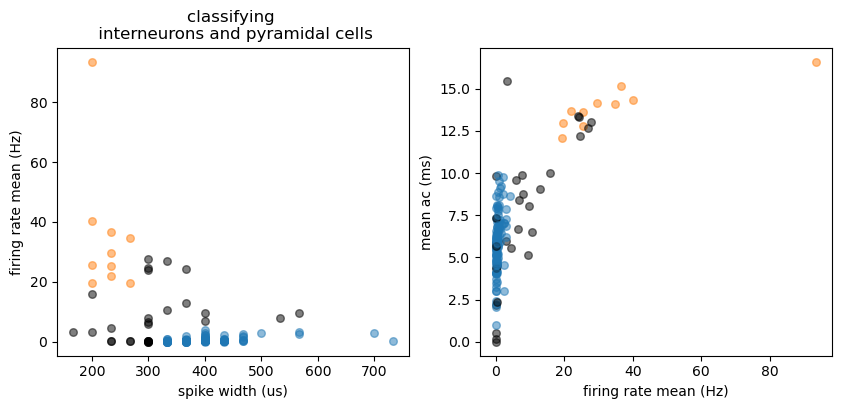

In [49]:
# Create a figure and a 3D axes
fig, axes = plt.subplots(1,2,figsize = (10,4))

# Plot the 3D scatter points
for (e,u) in firing_rate.keys():
    fr = firing_rate[(e,u)]
    w = np.abs(width[(e,u)])
    ac = ac_mean[(e,u)]
    c = classification[(e,u)]
    if c == "pyramidal":
        color = 'C0'
        if type_p == 0:
            label = "pyramidal"
        else:
            label = None
        type_p += 1
    elif c == "interneuron":
        color = 'C1'
        if type_i == 0:
            label = "interneuron"
        else:
            label = None
        type_i += 1
    else:
        color = 'k'
        if type_k == 0:
            label = "not classified"
        else:
            label = None
        type_k += 1
        
    axes[0].scatter(w*1000, fr, s=30, color = color, label = label, alpha = 0.5)
    axes[1].scatter(fr, ac, s=30, color = color, label = label, alpha = 0.5)

# Set labels
axes[0].set_xlabel('spike width (us)')
axes[0].set_ylabel("firing rate mean (Hz)")

axes[1].set_xlabel("firing rate mean (Hz)")
axes[1].set_ylabel('mean ac (ms)')

# Display the plot
axes[0].set_title('classifying \n interneurons and pyramidal cells')


plt.savefig(os.path.join(outputpath,
                         f"{nwb_copy_file_name}_{session_name}_2D.pdf"), transparent=False, bbox_inches='tight')

### insert into spyglass

In [50]:
result = result_to_dict(firing_rate, ac_mean, width, classification)

In [51]:
df = result_to_dataframe(result)
result_dict = df.to_dict()

In [52]:
df

firing_rate    ac_mean  spike_width classification
sort_group_id unit_id                                                    
2             2           9.712949   8.037907     0.566667   unclassified
              4           0.185921   2.186047     0.300000   unclassified
              5           6.897749   8.407063     0.400000   unclassified
              6           0.309733   5.173507     0.433333      pyramidal
              7           2.434022   2.981633     0.566667      pyramidal
...                            ...        ...          ...            ...
61            5          93.503224  16.606842     0.200000    interneuron
              6           0.249654   2.332884     0.300000   unclassified
              7           0.545991   7.540864     0.366667      pyramidal
              8           0.470486   5.884769     0.400000      pyramidal
              9           0.626367   9.901308     0.366667      pyramidal

[149 rows x 4 columns]

In [304]:
#test = pd.DataFrame.from_dict(test_dict)

In [54]:
key = {"nwb_file_name": nwb_copy_file_name,
      "epoch":int(session_name[:2]),
      "sorter":"mountainsort4",
      "curation_id":1,
      "cell_type_pd": result_dict}

In [55]:
SingleUnit().insert1(key)

In [60]:
q = {"nwb_file_name": nwb_copy_file_name,
      "epoch":int(session_name[:2]),
      "sorter":"mountainsort4",
      "curation_id":1}
cell_type_pd = pd.DataFrame.from_dict(
    (SingleUnit & q).fetch1("cell_type_pd")
)

In [61]:
cell_type_pd.loc[(2,4)]

firing_rate    ac_mean  spike_width classification
2  2     9.712949   8.037907     0.566667   unclassified
   4     0.185921   2.186047     0.300000   unclassified
   5     6.897749   8.407063     0.400000   unclassified
   6     0.309733   5.173507     0.433333      pyramidal
   7     2.434022   2.981633     0.566667      pyramidal
...           ...        ...          ...            ...
61 5    93.503224  16.606842     0.200000    interneuron
   6     0.249654   2.332884     0.300000   unclassified
   7     0.545991   7.540864     0.366667      pyramidal
   8     0.470486   5.884769     0.400000      pyramidal
   9     0.626367   9.901308     0.366667      pyramidal

[149 rows x 4 columns]